[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sprice134/DualSight/blob/master/demo.ipynb)


# Installing Imports

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install torch torchvision torchaudio
    !pip install git+https://github.com/facebookresearch/segment-anything.git
    !pip install opencv-python pycocotools matplotlib ipykernel
    !pip install ultralytics
    !mkdir -p models
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth -P models/
    !git clone https://github.com/sprice134/DualSight.git

In [11]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import cv2
from torch.utils.data import Dataset
from pathlib import Path
from ultralytics import YOLO
import yaml
from PIL import Image, ImageDraw

In [3]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def visualize_sample_with_labels(image, target, save_path):
    """
    Simple visualization of image, bounding boxes, and instance masks.
    """
    # Convert image tensor to [0,1] range for matplotlib
    image = image.permute(1, 2, 0).cpu().numpy()
    image = image - image.min()
    image = image / image.max()

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Draw predicted or GT masks
    masks = target['masks'].cpu().numpy()  # (N, H, W)
    for i, mask in enumerate(masks):
        mask = mask.squeeze()
        mask_color = mcolors.hsv_to_rgb([i / (len(masks)+1), 1, 1])
        ax.contour(mask, levels=[0.5], colors=[mask_color], linewidths=2)
        ax.imshow(np.ma.masked_where(mask == 0, mask), alpha=0.4, cmap='hsv')

    # Draw bounding boxes
    boxes = target['boxes'].cpu().numpy()
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis('off')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()
    print(f"Visualization saved to {save_path}")

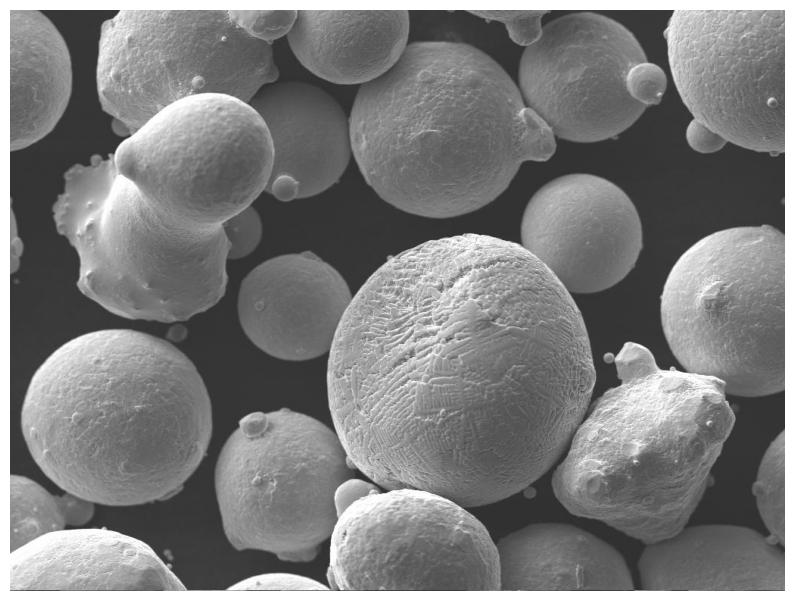

In [4]:
image_path = "DualSight/powder/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg"
image = cv2.imread(image_path)
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()


Using device: cuda
80
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


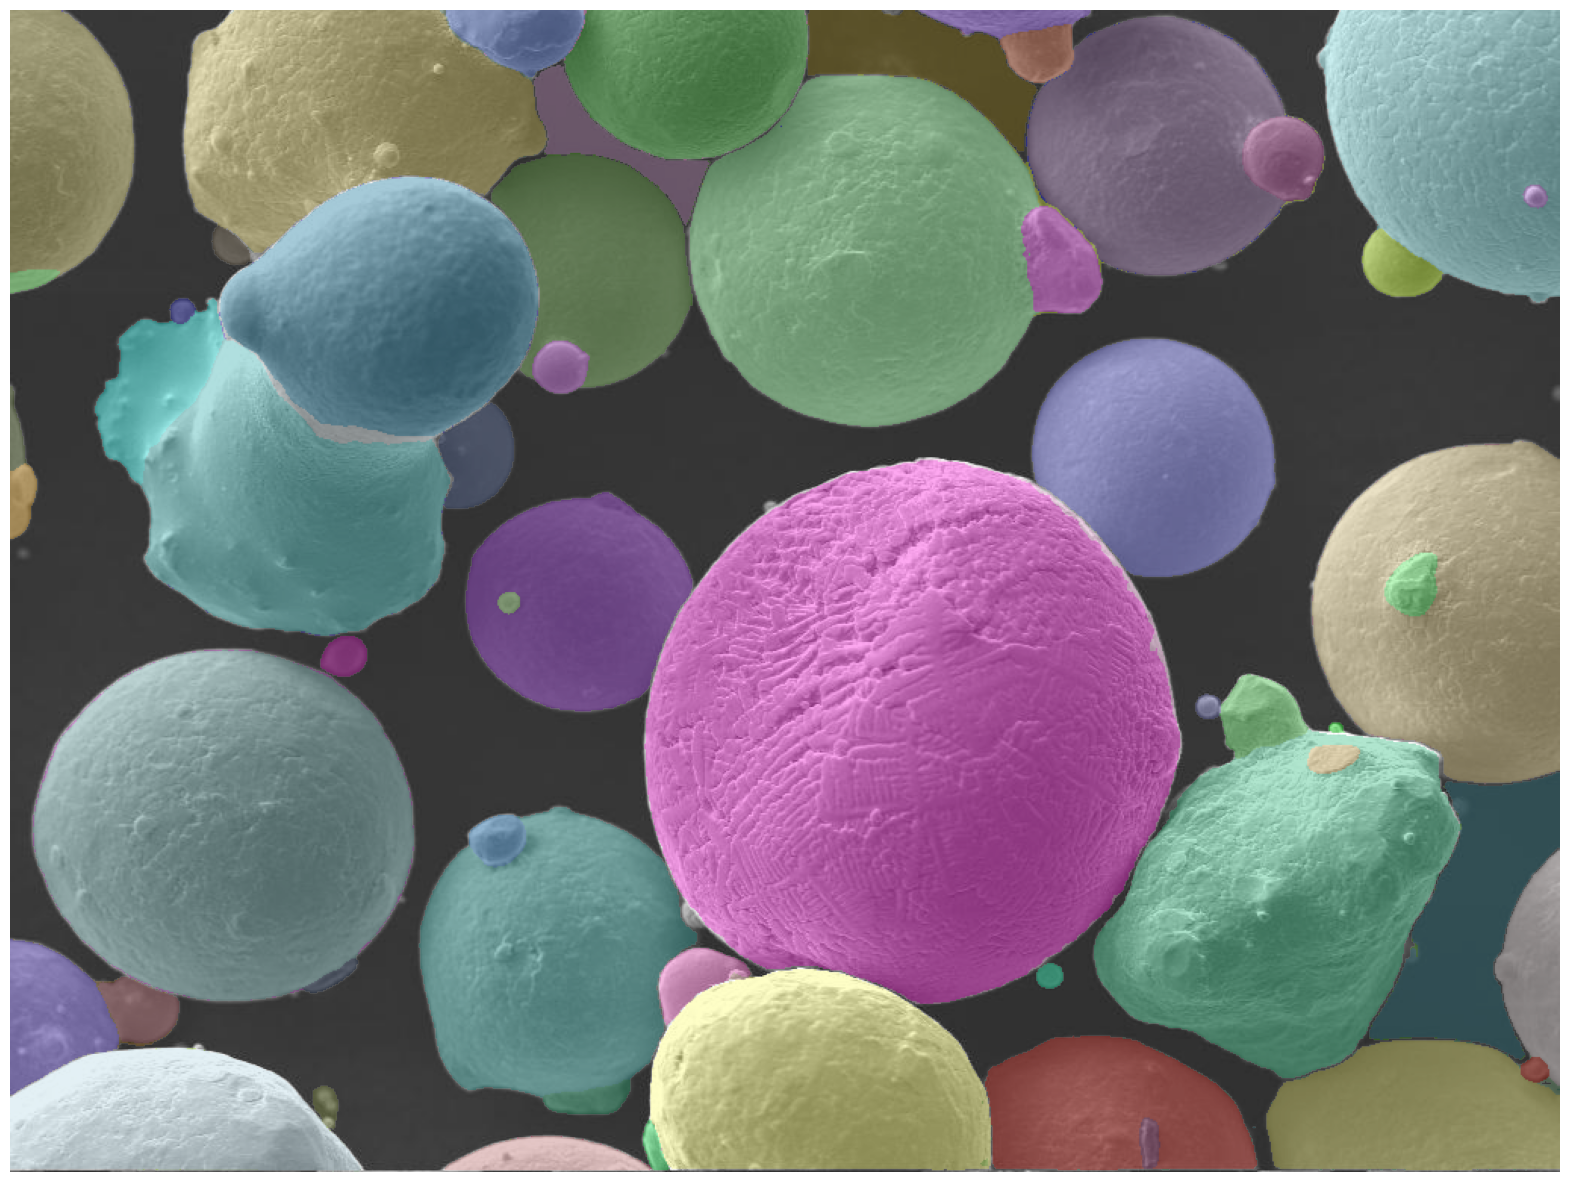

In [5]:
model_type = "vit_l"
checkpoint = "models/sam_vit_l_0b3195.pth"
image_path = "DualSight/powder/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg"


image = cv2.imread(image_path)
sam = sam_model_registry[model_type](checkpoint=checkpoint)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

# Generate masks for the image
masks = mask_generator.generate(image)

print(len(masks))
print(masks[0].keys())

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

In [6]:
def train_yolo(
    data_yaml="../powder/data.yaml",
    epochs=500,
    batch=16,
    device="0",
    model_size="n",
    output_dir='models/'
):
    """
    Trains a YOLOv8 segmentation model. Uses an ultralytics pretrained checkpoint
    (n, s, m, l, xl).
    """

    updated_yaml = update_yaml_paths(data_yaml)

    # Map from short 'model_size' to the ultralytics pretrained segmentation checkpoint
    size_map = {
        "n": "yolov8n-seg.pt",
        "s": "yolov8s-seg.pt",
        "m": "yolov8m-seg.pt",
        "l": "yolov8l-seg.pt",
        "x": "yolov8x-seg.pt",
        "xl": "yolov8x-seg.pt",  # 'x' and 'xl' point to the same file at time of writing
    }

    if YOLO is None:
        raise ImportError("The ultralytics package is not installed. Cannot train YOLO.")
    if model_size not in size_map:
        raise ValueError(f"Unknown model_size '{model_size}'. Choose from n, s, m, l, x, xl.")

    base_checkpoint = size_map[model_size]
    print(f"[YOLO] Using checkpoint: {base_checkpoint}")

    # Load the YOLO model
    model = YOLO(base_checkpoint)

    # Train
    model.train(
        data=updated_yaml,        # path to the data.yaml
        epochs=epochs,
        batch=batch,
        name=f"yolov8{model_size}-seg-train",
        project=output_dir     # This is where the training outputs will be saved
    )


class YoloV8SegmentationDataset(Dataset):
    """
    Example dataset for YOLOv8 polygon-based annotation files (.txt).
    Converts polygons into masks on the fly.
    """
    def __init__(self, image_dir, label_dir, transforms=None, image_size=(1024, 768)):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.transforms = transforms
        self.image_size = image_size

        self.image_files = sorted(list(self.image_dir.glob("*.jpg")))
        self.label_files = sorted(list(self.label_dir.glob("*.txt")))

    def __len__(self):
        return len(self.image_files)

    def _yolo_to_mask(self, label_path, image_size):
        """
        Convert YOLO polygon lines into a single binary mask for segmentation.
        """
        h, w = image_size
        mask = np.zeros((h, w), dtype=np.uint8)
        with open(label_path, "r") as f:
            for line in f:
                elements = line.strip().split()
                cls, *polygon_points = elements
                polygon_points = list(map(float, polygon_points))
                polygon_points = np.array(polygon_points, dtype=np.float32).reshape(-1, 2)

                # Scale up to image size
                polygon_points[:, 0] *= w
                polygon_points[:, 1] *= h
                polygon_points = polygon_points.astype(np.int32)

                # Fill the polygon to create instance regions
                cv2.fillPoly(mask, [polygon_points], color=1)
        return mask

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize(self.image_size)
        w, h = img.size

        label_path = self.label_files[idx]
        mask = self._yolo_to_mask(label_path, (h, w))

        if self.transforms:
            img = self.transforms(img)

        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask

def update_yaml_paths(yaml_path):
    """
    Loads a YAML file and updates the dataset paths (train, val, test)
    to be absolute paths based on the YAML file's directory.
    Returns the path to a temporary updated YAML file.
    """
    yaml_path = Path(yaml_path)
    base_dir = yaml_path.parent

    # Load the original YAML
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    # Update paths if they are not absolute
    for key in ['train', 'val', 'test']:
        if key in data:
            path_val = Path(data[key])
            if not path_val.is_absolute():
                # Prepend the base directory
                data[key] = str((base_dir / path_val).resolve())

    # Write updated YAML to a temporary file in the same directory
    temp_yaml_path = base_dir / "data_temp.yaml"
    with open(temp_yaml_path, "w") as f:
        yaml.dump(data, f)

    print(f"Updated YAML saved to: {temp_yaml_path}")
    return str(temp_yaml_path)


In [7]:
yaml_path = "powder/data.yaml"
if IN_COLAB:
    yaml_path = "DualSight/" + yaml_path

train_yolo(
    data_yaml="DualSight/powder/data.yaml",
    epochs=50,
    batch=16,
    model_size="n",  # or choose s, m, l, x, xl
    output_dir='models/'
)


Updated YAML saved to: DualSight/demo.v7i.yolov8/data_temp.yaml
[YOLO] Using checkpoint: yolov8n-seg.pt


100%|██████████| 6.74M/6.74M [00:00<00:00, 131MB/s]

Ultralytics 8.3.100 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=DualSight/demo.v7i.yolov8/data_temp.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=models/, name=yolov8n-seg-train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labe

100%|██████████| 755k/755k [00:00<00:00, 19.8MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  50%|█████     | 1/2 [00:01<00:01,  1.30s/it]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


                   all         33       2133      0.898      0.835      0.891      0.769      0.891      0.828      0.876      0.685
Speed: 0.2ms preprocess, 3.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to models/yolov8n-seg-train



image 1/1 /content/DualSight/demo.v7i.yolov8/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg: 480x640 26 Powders, 8.9ms
Speed: 2.7ms preprocess, 8.9ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)


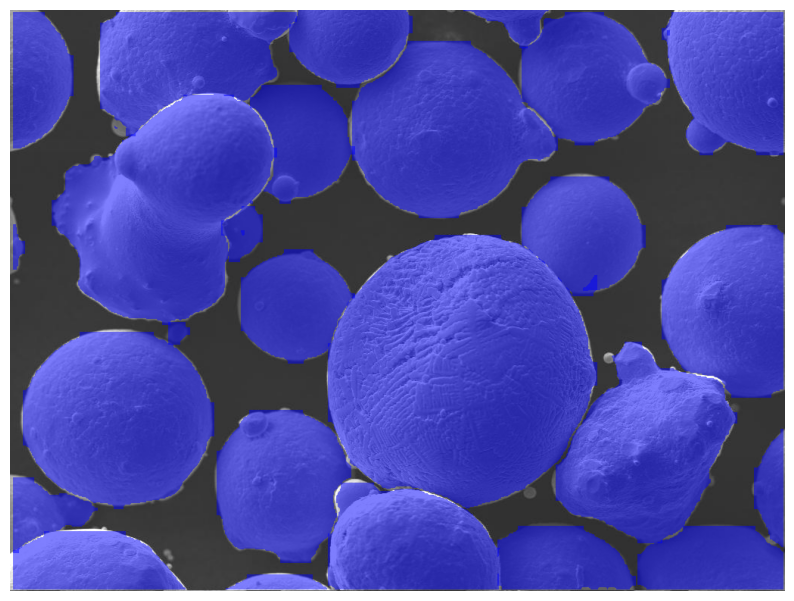

In [12]:
model = YOLO("models/yolov8n-seg-train/weights/best.pt")

sample_image = Image.open(image_path).convert('RGBA')
results = model.predict(source=image_path, conf=0.5)

for i in results[0]:
    polygon_points = i.masks.xy[0]
    if len(polygon_points) != 0:
        flat_polygon_points = [coord for pair in polygon_points for coord in pair]
        mask_img = Image.new('L', sample_image.size, 0)
        mask_draw = ImageDraw.Draw(mask_img)
        mask_draw.polygon(flat_polygon_points, outline=1, fill=255)
        mask_rgba = Image.new('RGBA', mask_img.size)
        red_mask = Image.new('RGBA', mask_img.size, (0, 0, 255, 128))
        mask_rgba.paste(red_mask, (0, 0), mask_img)
        sample_image = Image.alpha_composite(sample_image, mask_rgba)

plt.figure(figsize=(10, 10))
plt.imshow(sample_image)
plt.axis("off")
plt.show()





In [ ]:
import matplotlib.pyplot as plt  # For plotting
from PIL import Image, ImageDraw  # For loading and drawing on images
import numpy as np
from ultralytics import YOLO
import sys
sys.path.append("DualSight/utils/")
from samDemo import (
    show_mask, show_points, show_box, mask_to_polygon,
    generate_random_points_within_polygon, point_to_polygon_distance,
    find_optimal_points, polygon_to_binary_mask, expand_bbox_within_border,
    fractal_dimension, apply_mask_to_image
)
from segment_anything import sam_model_registry, SamPredictor
import torch
import cv2
from shapely.geometry import Polygon, Point
from itertools import combinations
import random
from skimage.draw import polygon
from skimage.measure import regionprops
from skimage.morphology import convex_hull_image
import math
import os

# Create the output directory if it doesn't exist.
os.makedirs('outputImages/', exist_ok=True)

# -------------------------
# YOLO Inference Integration
# -------------------------
# Load the trained YOLO segmentation model.
model = YOLO("models/yolov8n-seg-train/weights/best.pt")

# Define the sample image path.
sample_image_path = "DualSight/powder/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg"
# Run inference on the sample image.
results = model.predict(source=sample_image_path, conf=0.5)
result = results[0]

# -------------------------
# Existing Pipeline Integration
# -------------------------
# Load the sample image using PIL.
image_path = sample_image_path  # reusing the same image
image = Image.open(image_path).convert("RGBA")

# Setup the SAM model.
checkpoint = "models/sam_vit_l_0b3195.pth"
model_type = "vit_l"
device = "cuda"  # or "cpu" if CUDA is not available
sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# Load the image once for SAM predictions.
loop_image = cv2.imread(image_path)
predictor.set_image(loop_image)

listOfPolygons = []
listOfBoxes = []

# Use YOLO inference results to extract polygon and box information.
results = model(image)
for i in results[0]:
    polygon_points = i.masks.xy[0]  # Get polygon points for the mask.
    if len(polygon_points) > 2:
        listOfPolygons.append(polygon_points)
        listOfBoxes.append(i.boxes.xyxy[0])

polygons = []
masksList = []

# For each detected instance from YOLO, run SAM prediction.
for INDEX in range(len(listOfPolygons)):
    poly = listOfPolygons[INDEX]
    box = listOfBoxes[INDEX]
    box = box.cpu().numpy()
    # Expand the bounding box slightly.
    box = np.array(expand_bbox_within_border(
        box[0], box[1], box[2], box[3],
        image.width, image.height, expansion_rate=0.1))
    # Convert the polygon to a binary mask.
    mask = polygon_to_binary_mask(poly, image.height, image.width)
    concave_polygon = Polygon(poly)
    sampled_points = generate_random_points_within_polygon(concave_polygon, 50)
    optimal_points = find_optimal_points(sampled_points, concave_polygon, num_result_points=3, border_weight=2)
    optimal_points_xy = [[point.x, point.y] for point in optimal_points]
    input_point = np.array(optimal_points_xy)
    input_label = np.array([1] * len(optimal_points_xy))  # All points are positive.

    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        box=box[None, :],
        multimask_output=True,
    )

    # For this instance, take the first (best) mask.
    if len(masks) > 0:
        masksList.append(masks[0])
        convertedPolygon = mask_to_polygon(masks[0])
        polygons.append(convertedPolygon)

# -------------------------
# YOLO Outputs (Composite Mask and Overlay)
# -------------------------
# Create a composite YOLO mask from YOLO predictions.
yolo_composite_mask = np.zeros((image.height, image.width), dtype=bool)
for i in results[0]:
    polygon_points = i.masks.xy[0]
    if len(polygon_points) > 2:
        mask = polygon_to_binary_mask(polygon_points, image.height, image.width)
        yolo_composite_mask = np.logical_or(yolo_composite_mask, mask)

# Save the YOLO composite mask.
yolo_mask_img = (yolo_composite_mask.astype(np.uint8) * 255)
Image.fromarray(yolo_mask_img).save("outputImages/yoloMask.png")

# Create YOLO overlay image using a blue transparent color.
color_with_alpha_yolo = np.array([0, 0, 255, 0.5])
result_yolo_image = apply_mask_to_image(image_path, yolo_composite_mask, color_with_alpha_yolo)
result_yolo_image.save("outputImages/yoloImage.png")

# -------------------------
# SAM Outputs
# -------------------------
# Combine all SAM masks into one composite mask.
composite_mask = np.zeros_like(masksList[0])
for mask in masksList:
    composite_mask = np.logical_or(composite_mask, mask)
composite_mask_for_image = (composite_mask.astype(np.uint8) * 255)

# Save SAM mask output.
composite_image = Image.fromarray(composite_mask_for_image)
composite_image.save("outputImages/samMask.png")

# Save SAM overlay image (apply composite mask to the original image).
color_with_alpha = np.array([255, 0, 0, 0.5])  # Transparent Red.
result_image = apply_mask_to_image(image_path, composite_mask, color_with_alpha)
result_image.save("outputImages/samImage.png")

# -------------------------
# Display YOLO and SAM Overlay Images
# -------------------------
# Load images for display.
yolo_overlay = Image.open("outputImages/yoloImage.png")
sam_overlay = Image.open("outputImages/samImage.png")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(yolo_overlay)
plt.title("YOLO Overlay Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sam_overlay)
plt.title("SAM Overlay Image")
plt.axis("off")

plt.show()


FileNotFoundError: DualSight/powder/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg does not exist